# Wine Quality Prediction

**Task:** Predict wine quality using chemical properties with three classifier models.

**Dataset:** `WineQT.csv` — 1,144 red wine samples with 11 chemical features.

---
### Dataset Columns
| Feature | Description |
|---------|-------------|
| `fixed acidity` | Tartaric acid concentration |
| `volatile acidity` | Acetic acid — too high causes vinegar taste |
| `citric acid` | Adds freshness and flavour |
| `residual sugar` | Sugar remaining after fermentation |
| `chlorides` | Salt content |
| `free sulfur dioxide` | Free SO₂ prevents microbial growth |
| `total sulfur dioxide` | Total SO₂ (free + bound) |
| `density` | Density relative to water |
| `pH` | Acidity level (0=very acidic, 14=very basic) |
| `sulphates` | Wine additive contributing to SO₂ |
| `alcohol` | Alcohol % by volume |
| `quality` | **Target** — score between 3 and 8 |

---
### Pipeline
| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load & Explore |
| 3 | Data Cleaning |
| 4 | EDA & Visualization |
| 5 | Feature Engineering |
| 6 | Model Training (RF, SGD, SVC) |
| 7 | Evaluation & Comparison |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


## 2. Load Dataset & Initial Exploration

In [2]:
# Load dataset
df = pd.read_csv('WineQT.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# Column types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
# Statistical summary
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
# Check missing values
print('Missing values:\n', df.isnull().sum())
print('\nQuality score range:', df['quality'].min(), '—', df['quality'].max())
print('Quality distribution:')
print(df['quality'].value_counts().sort_index())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Quality score range: 3 — 8
Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


## 3. Data Cleaning

In [6]:
# Drop the Id column — not a feature
df.drop(columns=['Id'], inplace=True)

# Remove exact duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - df.shape[0]}')
print(f'Clean shape: {df.shape}')

Duplicates removed: 125
Clean shape: (1018, 12)


## 4. EDA & Visualization

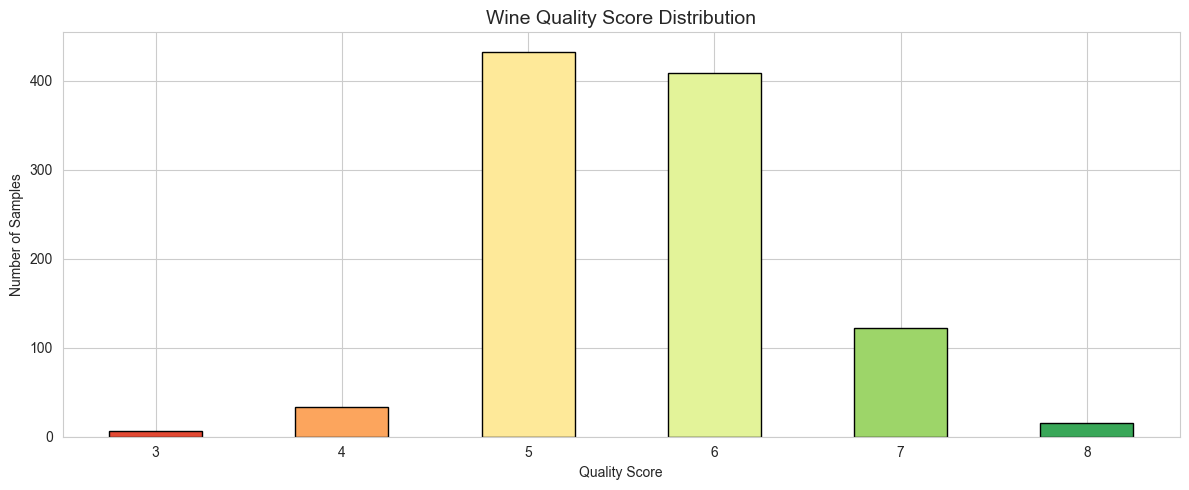

In [7]:
# Quality score distribution
quality_counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', len(quality_counts))

quality_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Wine Quality Score Distribution', fontsize=14)
plt.xlabel('Quality Score')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

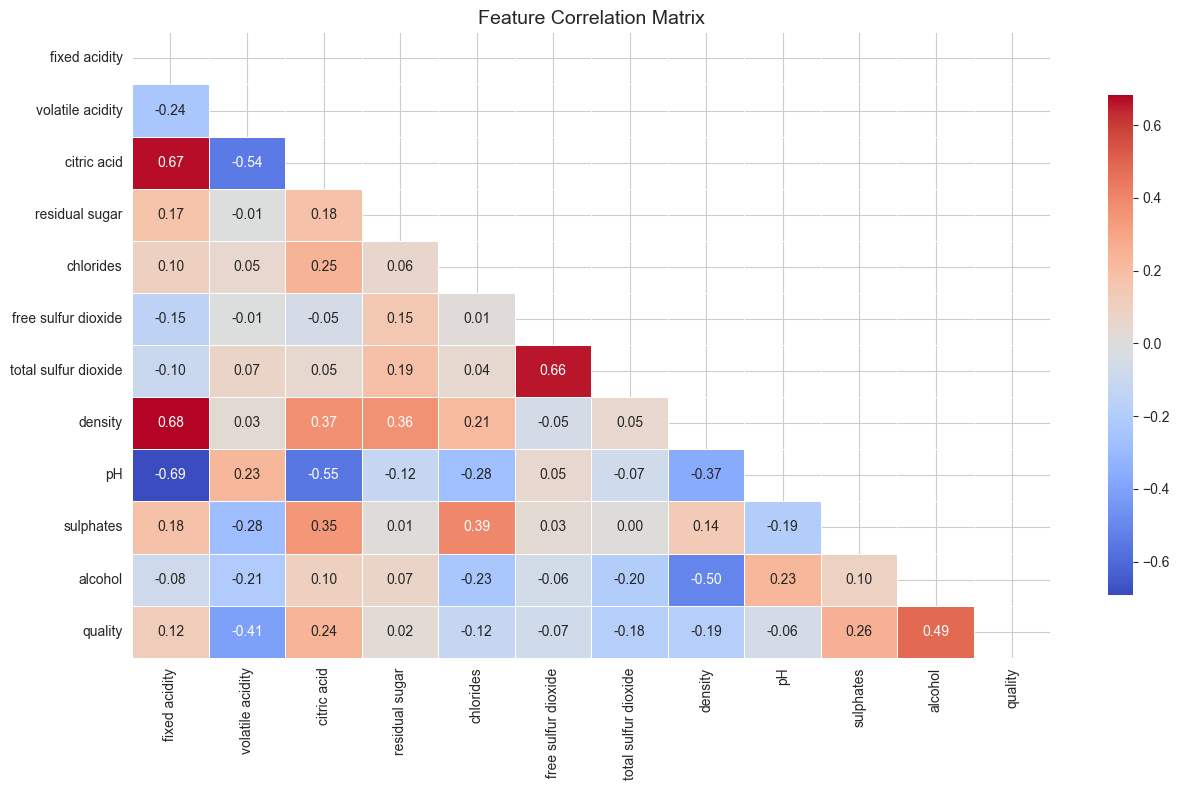

In [8]:
# Correlation heatmap — find which chemicals relate most to quality
plt.figure(figsize=(13, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

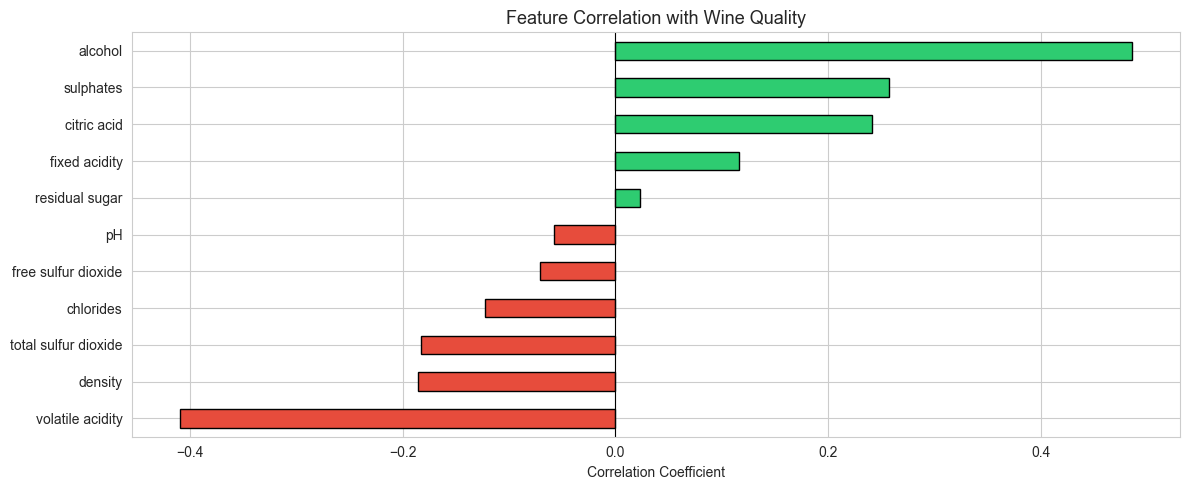

In [9]:
# Top correlations with quality
corr_quality = corr['quality'].drop('quality').sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_quality]

corr_quality.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Correlation with Wine Quality', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

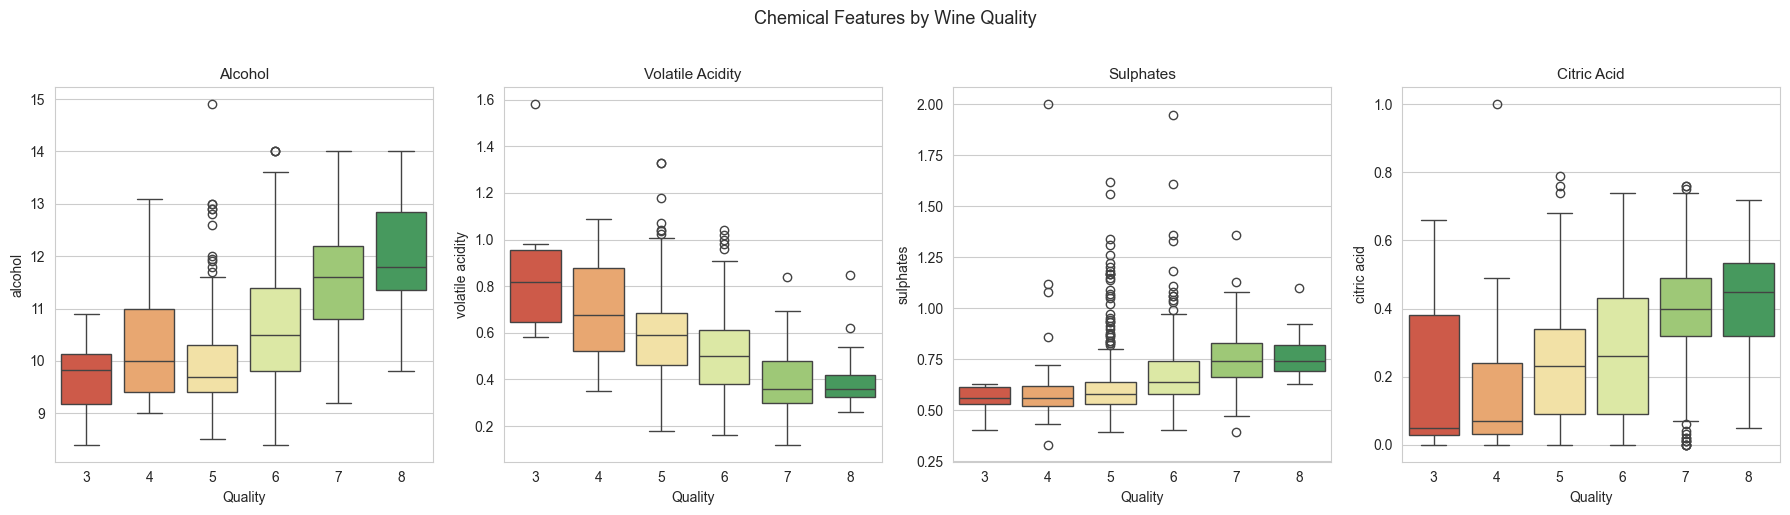

In [10]:
# Boxplots: key chemical features grouped by quality score
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df, x='quality', y=feat, palette='RdYlGn', ax=ax)
    ax.set_title(feat.title(), fontsize=11)
    ax.set_xlabel('Quality')

plt.suptitle('Chemical Features by Wine Quality', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

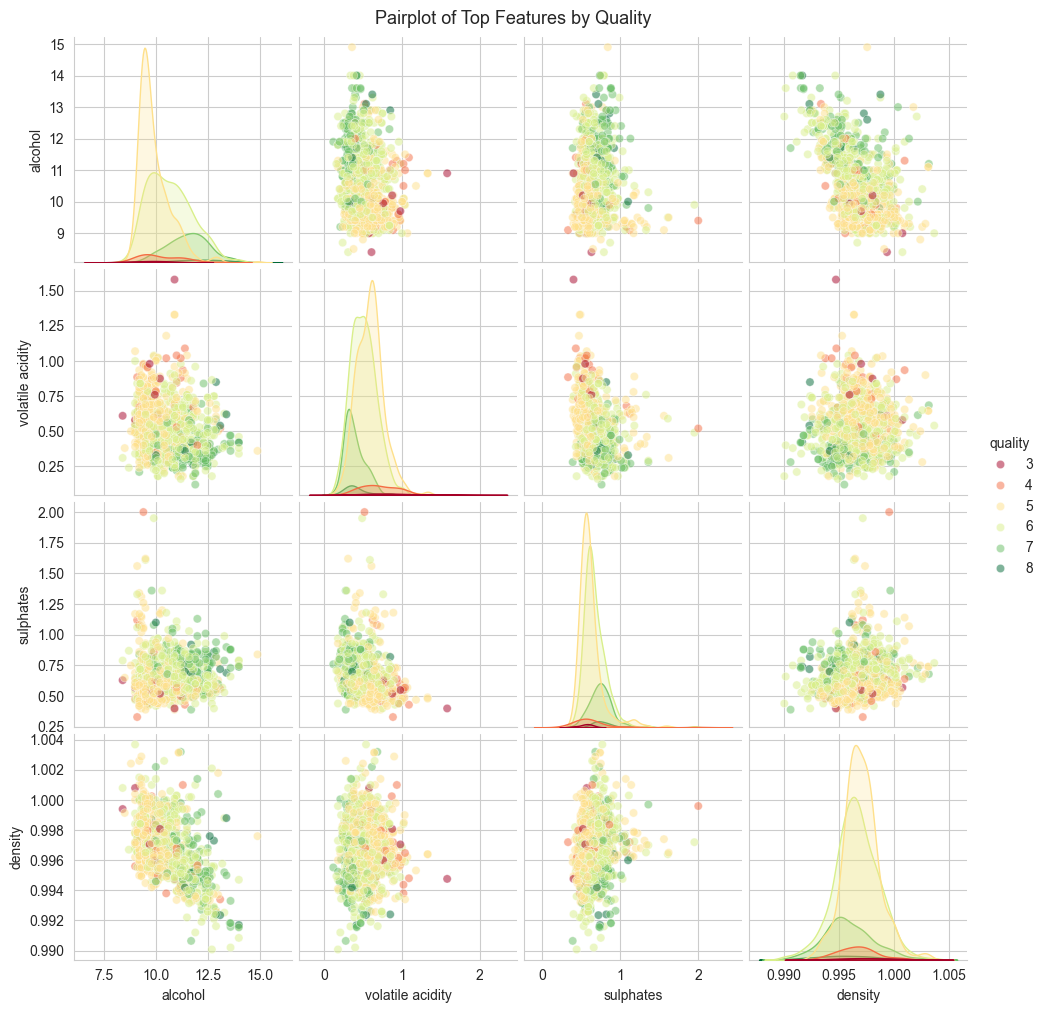

In [11]:
# Pairplot of top 4 features
top4 = ['alcohol', 'volatile acidity', 'sulphates', 'density', 'quality']
sns.pairplot(df[top4], hue='quality', palette='RdYlGn', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Top Features by Quality', y=1.01, fontsize=13)
plt.show()

## 5. Feature Engineering

> Wine quality scores 3–5 → **Low**, 6 → **Medium**, 7–8 → **High** for a simplified 3-class problem.

In [12]:
# Create binary sentiment-style label: Good (>=6) vs Bad (<6)
df['quality_label'] = df['quality'].apply(
    lambda q: 'Low' if q <= 5 else ('High' if q >= 7 else 'Medium')
)

print('Simplified class distribution:')
print(df['quality_label'].value_counts())

Simplified class distribution:
quality_label
Low       472
Medium    409
High      137
Name: count, dtype: int64


In [13]:
# Encode string labels to integers
le = LabelEncoder()
df['quality_encoded'] = le.fit_transform(df['quality_label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Define features and target
X = df.drop(columns=['quality', 'quality_label', 'quality_encoded'])
y = df['quality_encoded']

print(f'\nFeatures: {X.shape[1]}  |  Samples: {X.shape[0]}')

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Features: 11  |  Samples: 1018


In [14]:
# Train/test split and feature scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}')

Train: 814 | Test: 204


## 6. Model Training

### 6.1 Random Forest Classifier

In [15]:
# Random Forest — ensemble of decision trees, robust to outliers
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Random Forest ===
Accuracy : 0.6471
              precision    recall  f1-score   support

        High       0.62      0.48      0.54        27
         Low       0.68      0.83      0.75        95
      Medium       0.60      0.49      0.54        82

    accuracy                           0.65       204
   macro avg       0.63      0.60      0.61       204
weighted avg       0.64      0.65      0.64       204



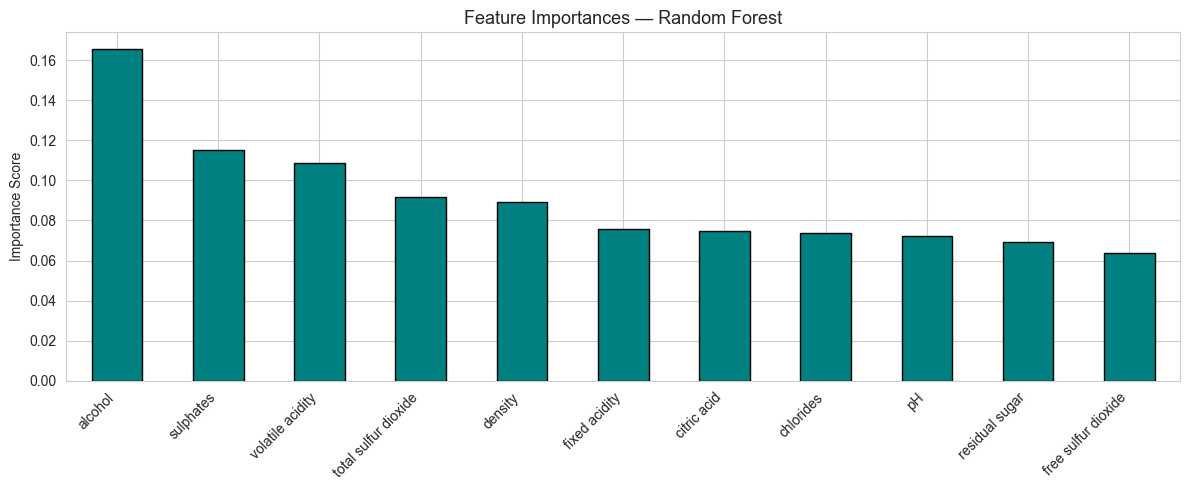

In [16]:
# Feature importances from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Stochastic Gradient Descent (SGD)

In [17]:
# SGD — efficient linear classifier, good for large datasets
sgd = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42, loss='hinge')
sgd.fit(X_train_sc, y_train)

y_pred_sgd = sgd.predict(X_test_sc)

print('=== SGD Classifier ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_sgd):.4f}')
print(classification_report(y_test, y_pred_sgd, target_names=le.classes_))

=== SGD Classifier ===
Accuracy : 0.5784
              precision    recall  f1-score   support

        High       0.50      0.74      0.60        27
         Low       0.63      0.80      0.70        95
      Medium       0.51      0.27      0.35        82

    accuracy                           0.58       204
   macro avg       0.55      0.60      0.55       204
weighted avg       0.56      0.58      0.55       204



### 6.3 Support Vector Classifier (SVC)

In [18]:
# SVC with RBF kernel — finds optimal hyperplane separating classes
svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc.fit(X_train_sc, y_train)

y_pred_svc = svc.predict(X_test_sc)

print('=== Support Vector Classifier ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_svc):.4f}')
print(classification_report(y_test, y_pred_svc, target_names=le.classes_))

=== Support Vector Classifier ===
Accuracy : 0.6176
              precision    recall  f1-score   support

        High       0.58      0.41      0.48        27
         Low       0.67      0.78      0.72        95
      Medium       0.55      0.50      0.53        82

    accuracy                           0.62       204
   macro avg       0.60      0.56      0.57       204
weighted avg       0.61      0.62      0.61       204



## 7. Evaluation & Comparison

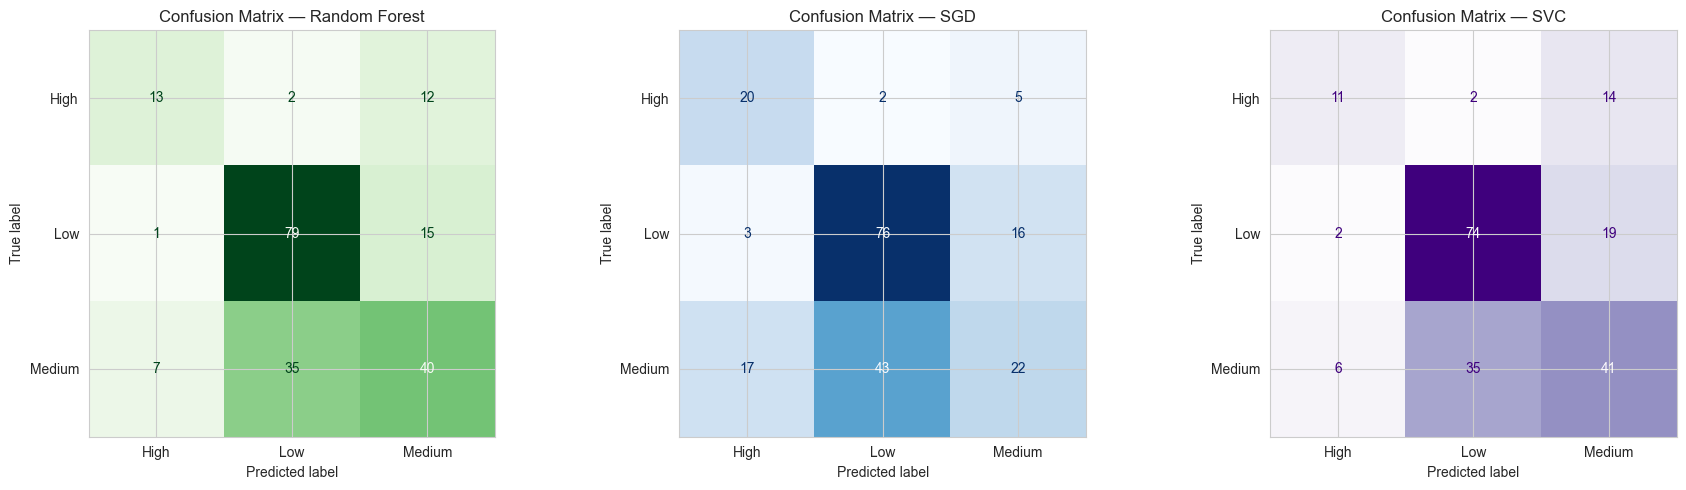

In [19]:
# Confusion matrices for all three models
models     = [rf,         sgd,         svc]
preds      = [y_pred_rf,  y_pred_sgd,  y_pred_svc]
names      = ['Random Forest', 'SGD', 'SVC']
cmaps      = ['Greens', 'Blues', 'Purples']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, name, cmap in zip(axes, preds, names, cmaps):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)

plt.tight_layout()
plt.show()

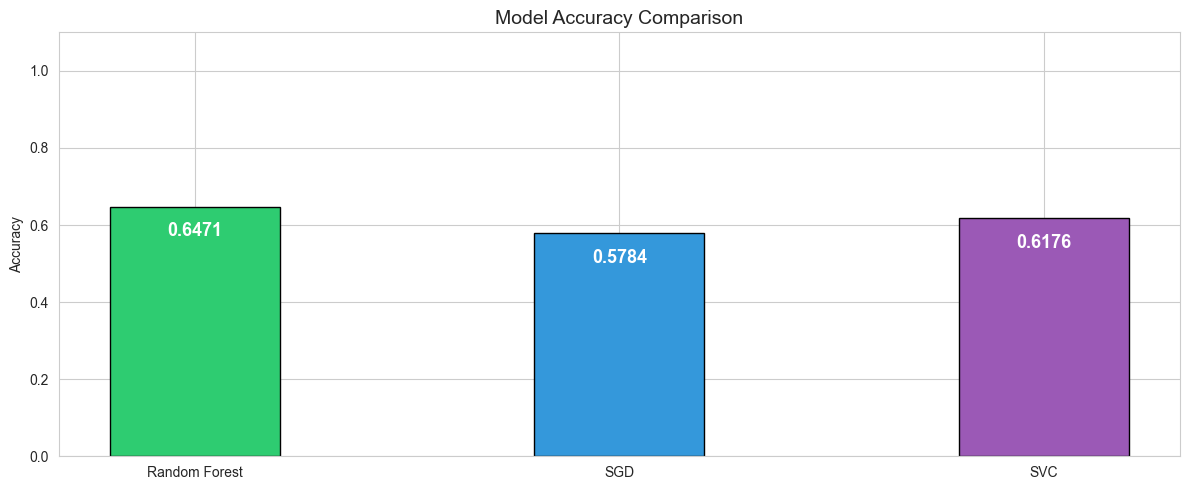

In [20]:
# Accuracy bar comparison
accuracies = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_sgd),
    accuracy_score(y_test, y_pred_svc)
]

colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = plt.bar(names, accuracies, color=colors, edgecolor='black', width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 0.04,
             f'{acc:.4f}', ha='center', va='top',
             color='white', fontweight='bold', fontsize=13)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [21]:
# 5-fold cross-validation for all models
print('=== 5-Fold Cross-Validation Accuracy ===')
for name, model in zip(names, models):
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    print(f'{name:20s} → Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

=== 5-Fold Cross-Validation Accuracy ===
Random Forest        → Mean: 0.6413  Std: 0.0130
SGD                  → Mean: 0.5737  Std: 0.0454
SVC                  → Mean: 0.6413  Std: 0.0197


In [22]:
# Summary table
summary = pd.DataFrame({
    'Model'   : names,
    'Accuracy': [f'{a:.4f}' for a in accuracies]
})

print('\n=== Final Model Summary ===')
print(summary.to_string(index=False))


=== Final Model Summary ===
        Model Accuracy
Random Forest   0.6471
          SGD   0.5784
          SVC   0.6176


## 8. Predict Quality for a New Wine Sample

In [23]:
# Sample new wine with chemical properties
new_wine = pd.DataFrame([{
    'fixed acidity'       : 7.4,
    'volatile acidity'    : 0.70,
    'citric acid'         : 0.00,
    'residual sugar'      : 1.9,
    'chlorides'           : 0.076,
    'free sulfur dioxide' : 11.0,
    'total sulfur dioxide': 34.0,
    'density'             : 0.9978,
    'pH'                  : 3.51,
    'sulphates'           : 0.56,
    'alcohol'             : 9.4
}])

new_wine_sc = scaler.transform(new_wine)

print('=== Predictions for New Wine Sample ===')
for name, model in zip(names, models):
    pred_label = le.inverse_transform(model.predict(new_wine_sc))[0]
    print(f'{name:20s} → Quality Category: {pred_label}')

=== Predictions for New Wine Sample ===
Random Forest        → Quality Category: Low
SGD                  → Quality Category: Low
SVC                  → Quality Category: Low


## 9. Summary

| Item | Detail |
|------|--------|
| Dataset | WineQT.csv — 1,144 red wine samples, 11 chemical features |
| Target | `quality` score (3–8) grouped into Low / Medium / High |
| Scaling | StandardScaler (zero mean, unit variance) |
| Model 1 | **Random Forest** — ensemble of 100 decision trees |
| Model 2 | **SGD Classifier** — linear model with hinge loss |
| Model 3 | **SVC** — RBF kernel support vector classifier |
| Best Feature | `alcohol` (highest positive correlation with quality) |
| Worst Feature | `volatile acidity` (highest negative correlation) |

> **Key Insight:** Higher alcohol content and lower volatile acidity are the strongest predictors of better wine quality.